In [ ]:
# Upload CSV File
from google.colab import files
uploaded = files.upload()



Saving Processed_NASDAQ.csv to Processed_NASDAQ (1).csv


In [ ]:
# Load and Clean the Data
import pandas as pd

df = pd.read_csv("Processed_NASDAQ.csv")  # Or any of the other 4 files
df = df.drop(columns=["Date", "Name"], errors="ignore")
df.dropna(inplace=True)
print(df.head())


           Close    Volume       mom      mom1      mom2      mom3     ROC_5  \
201  2436.949951  0.299836 -0.017620  0.004816  0.013710 -0.002396  0.787041   
202  2457.389893 -0.100395  0.008388 -0.017620  0.004816  0.013710  0.661958   
203  2459.669922  0.058861  0.000928  0.008388 -0.017620  0.004816  0.997382   
206  2497.290039  0.096219  0.002585  0.004622  0.008017  0.000928  2.476050   
207  2503.260010  0.051657  0.002391  0.002585  0.004622  0.008017  1.866619   

       ROC_10    ROC_15    ROC_20  ...   NZD  silver-F  RUSSELL-F  S&P-F  \
201  1.546771  2.410493  3.728685  ... -1.84     -2.59      -1.74  -1.23   
202  3.223055  3.401127  5.261821  ...  1.40      1.03       0.91   0.94   
203  3.188361  3.844002  5.697692  ... -0.98     -3.69      -0.53   0.09   
206  3.282578  4.061119  4.946228  ... -0.52      2.42      -0.23   0.00   
207  2.540933  5.149837  5.331233  ...  0.03     -2.97      -0.26  -0.34   

      CHF  Dollar index-F  Dollar index  wheat-F   XAG   XAU  

In [26]:
# Normalize the Data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df.values)
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)


In [27]:
# Create Prediction Labels
# For Regression(predict next day's closing price)
df["Target"] = df["Close"].shift(-1)
df.dropna(inplace=True)  # Drop the last row which now has a NaN target
print(df.head())

           Close    Volume       mom      mom1      mom2      mom3     ROC_5  \
201  2436.949951  0.299836 -0.017620  0.004816  0.013710 -0.002396  0.787041   
202  2457.389893 -0.100395  0.008388 -0.017620  0.004816  0.013710  0.661958   
203  2459.669922  0.058861  0.000928  0.008388 -0.017620  0.004816  0.997382   
206  2497.290039  0.096219  0.002585  0.004622  0.008017  0.000928  2.476050   
207  2503.260010  0.051657  0.002391  0.002585  0.004622  0.008017  1.866619   

       ROC_10    ROC_15    ROC_20  ...  silver-F  RUSSELL-F  S&P-F   CHF  \
201  1.546771  2.410493  3.728685  ...     -2.59      -1.74  -1.23  1.27   
202  3.223055  3.401127  5.261821  ...      1.03       0.91   0.94 -1.01   
203  3.188361  3.844002  5.697692  ...     -3.69      -0.53   0.09  0.64   
206  3.282578  4.061119  4.946228  ...      2.42      -0.23   0.00  1.17   
207  2.540933  5.149837  5.331233  ...     -2.97      -0.26  -0.34  0.47   

     Dollar index-F  Dollar index  wheat-F   XAG   XAU       T

In [28]:
df["Target"] = df["Close"].shift(-1)
df.dropna(inplace=True)  # Drop the last row which now has a NaN target


In [29]:
# Create Time Series Windows
import numpy as np

window_size = 60
X = []
y = []

features = df.drop(columns=["Target"]).values
labels = df["Target"].values

for i in range(window_size, len(df)):
    X.append(features[i - window_size:i])
    y.append(labels[i])

X = np.array(X)
y = np.array(y)

# Reshape for CNN: [samples, channels=1, features, timesteps]
X = np.transpose(X, (0, 2, 1))  # [samples, features, timesteps]
X = X[:, np.newaxis, :, :]     # Add channel dimension: [samples, 1, features, timesteps]


In [30]:
# Train and Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)


In [31]:
# Build the CNN Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, kernel_size=(1, 3), activation='relu', input_shape=(1, X.shape[2], X.shape[3])),
    MaxPooling2D(pool_size=(1, 2)),
    Conv2D(64, kernel_size=(1, 3), activation='relu'),
    MaxPooling2D(pool_size=(1, 2)),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Regression: 1 output neuron, no activation
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Model Compilation and Training
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 436485.1562 - mae: 515.2812 - val_loss: 14141.0713 - val_mae: 98.7003
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 290541.8125 - mae: 431.4401 - val_loss: 25570.0176 - val_mae: 130.1659
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 263731.0625 - mae: 393.3601 - val_loss: 84713.6953 - val_mae: 272.3069
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 226252.5156 - mae: 373.8255 - val_loss: 9862.2578 - val_mae: 82.5278
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 262171.0000 - mae: 412.0808 - val_loss: 262753.5625 - val_mae: 504.2660
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 295188.9375 - mae: 427.8888 - val_loss: 21293.3477 - val_mae: 121.8304
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 268276.6250 - mae: 402.3548 - val_loss: 42932.6367 - val_mae: 185.7397
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 255896.0156 - mae: 404.0392 - val

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17926.7012 - mae: 105.1962 
Test MAE: 89.10742950439453
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


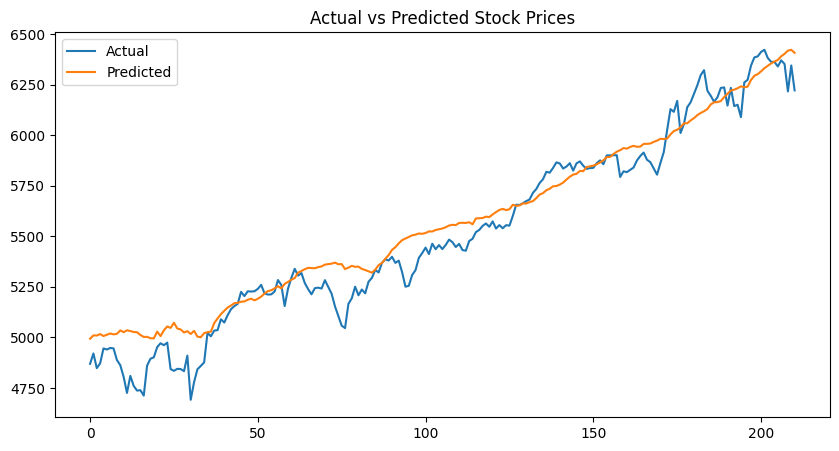

In [ ]:
# Evaluating trained CNN model and visualizing prediction
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae}")

# Predictions
preds = model.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Stock Prices")
plt.show()
